# Fine-tuning a Pre-trained Convolutional Neural Network for the Grainset Image Dataset

TODO: Address Class Imbalance (Classes having very low f1-score)
- Augmentation
- Checkpointing
- lr scaler

For our Neural Network, we will use a pre-trained model in order to perform classification tasks. We chose a CNN model, specifically EfficientNetV2-small, in order to utilize its convolutional blocks that can extract features from the images.

In [1]:
import matplotlib.pyplot as plt
from neural_network_utils import (
    GrainDataModule,
    IDX_TO_CLASS,
    LightningModel,
    plot_loss_and_acc,
)
import lightning as L
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext watermark
%watermark -p torch,lightning,torchvision,torchmetrics


torch       : 2.10.0
lightning   : 2.6.1
torchvision : 0.25.0
torchmetrics: 1.8.2



## Preparing the Pre-Trained Model

We will use the EfficientNetV2-small model pretrained using the Imagenet1K-v1 dataset in order to leverage the feature extraction ability that the model has acquired when training the model on the thousand classes of images on the dataset.

In [3]:
efficientnet_v2_s = torch.hub.load(
    "pytorch/vision:v0.25.0", "efficientnet_v2_s", weights="IMAGENET1K_V1"
)

Using cache found in /home/xandreiathome/.cache/torch/hub/pytorch_vision_v0.25.0


In [4]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [5]:
for param in efficientnet_v2_s.parameters():
    param.requires_grad = False

# EfficientNet's final layer is classifier[1], not fc
efficientnet_v2_s.classifier[1] = torch.nn.Linear(1280, 16)

In [6]:
efficientnet_v2_s

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [7]:
from torchvision.models import EfficientNet_V2_S_Weights

weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

## Preparing the Dataset and Loaders
A quick check in order to make sure that the dataloader is able to load the images properly

In [8]:
data_module = GrainDataModule(
    data_dir="dataset/images",
    batch_size=32,
    train_transform=preprocess_transform,
    val_transform=preprocess_transform,
    test_transform=preprocess_transform,
)

In [9]:
data_module.setup()

In [10]:
print("Train size:", len(data_module.train_dataset))
print("Val size:", len(data_module.val_dataset))
print("Test size:", len(data_module.test_dataset))

Train size: 38220
Val size: 6742
Test size: 5000


In [11]:
train_loader = data_module.train_dataloader()

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 384, 384])
torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1975338].


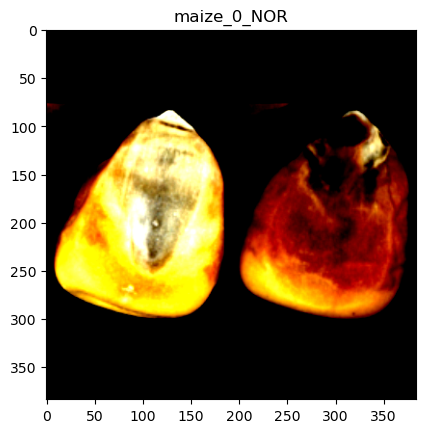

In [12]:
img = images[0].permute(1, 2, 0)

plt.imshow(img)
plt.title(IDX_TO_CLASS[labels[0].item()])
plt.show()

# Fine Tuning the Model

We will use the utility tuners that come with Lightning in order to find a good baseline for the learning rate and batch sizes.

In [13]:
L.seed_everything(67)

debug_lightning_model = LightningModel(
    model=efficientnet_v2_s, learning_rate=0.01, num_classes=16
)

debug_trainer = L.Trainer(
    accelerator="gpu",
    devices="auto",
    logger=None,
    deterministic=True,
)

Seed set to 67
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [14]:
from lightning.pytorch.tuner import Tuner

In [15]:
tuner = Tuner(debug_trainer)

new_batch_size = tuner.scale_batch_size(
    model=debug_lightning_model, datamodule=data_module, mode="power"
)

print(new_batch_size)

/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.
/home/xandreiathome/.conda/envs/python3.12/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree

128


In [16]:
data_module.batch_size = 64

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/xandreiathome/Work/class-code/mco/image-recognition-mco/.lr_find_08df4c11-d77a-45e6-945b-cb77a2e44f20.ckpt
Restored all states from the checkpoint at /home/xandreiathome/Work/class-code/mco/image-recognition-mco/.lr_find_08df4c11-d77a-45e6-945b-cb77a2e44f20.ckpt
Learning rate set to 0.0001
/tmp/ipykernel_79567/3403808000.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


0.0001


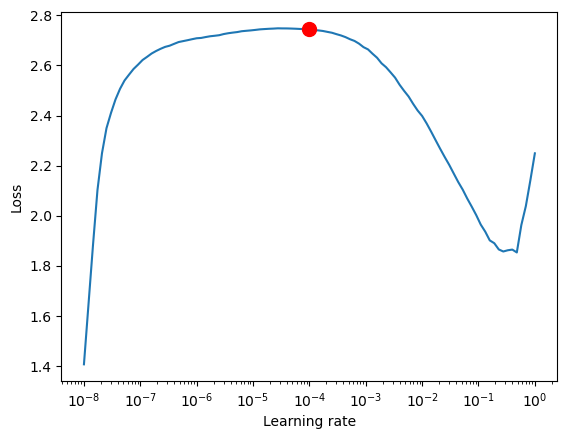

In [17]:
lr_finder = tuner.lr_find(debug_lightning_model, datamodule=data_module)

# Plot
fig = lr_finder.plot(suggest=True)
fig.show()

# Get suggested LR
new_lr = lr_finder.suggestion()
print(new_lr)

In [ ]:
lightning_model = LightningModel(
    model=efficientnet_v2_s, learning_rate=0.0001, num_classes=16
)

trainer = L.Trainer(
    fast_dev_run=10,
    max_epochs=30,
    accelerator="gpu",
    devices="auto",
    logger=CSVLogger(save_dir="logs/", name="tuned-efficientnet"),
    deterministic=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 10 batch(es). Logging and checkpointing is suppressed.


In [23]:
trainer.fit(model=lightning_model, datamodule=data_module)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                     ┃ Type                ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                    │ EfficientNet        │ 20.2 M │ train │     0 │
│ 1 │ train_acc                │ MulticlassAccuracy  │      0 │ train │     0 │
│ 2 │ val_acc                  │ MulticlassAccuracy  │      0 │ train │     0 │
│ 3 │ test_acc                 │ MulticlassAccuracy  │      0 │ train │     0 │
│ 4 │ test_precision           │ MulticlassPrecision │      0 │ train │     0 │
│ 5 │ test_recall              │ MulticlassRecall    │      0 │ train │     0 │
│ 6 │ test_f1                  │ MulticlassF1Score   │      0 │ train │     0 │
│ 7 │ test_precision_per_class │ MulticlassPrecision │      0 │ train │     0 │
│ 8 │ test_recall_per_class    │ MulticlassRecall    │      0 │ train │     0 │
│ 9 │ test_f1_per_class        │ MulticlassF1Score   │      0 │ train │     0 │
└───┴──────────────────────────┴─────────────────────┴────────┴───────┴───────┘

Trainable params: 20.5 K                                                                                           
Non-trainable params: 20.2 M                                                                                       
Total params: 20.2 M                                                                                               
Total estimated model params size (MB): 80                                                                         
Modules in train mode: 723                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_steps=10` reached.


In [32]:
trainer.test(model=lightning_model, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.4124999940395355     │
│          test_f1          │    0.5840708017349243     │
│      test_f1_class_0      │    0.5656024217605591     │
│      test_f1_class_1      │            0.0            │
│     test_f1_class_10      │            0.0            │
│     test_f1_class_11      │            0.0            │
│     test_f1_class_12      │            0.0            │
│     test_f1_class_13      │            0.0            │
│     test_f1_class_14      │            0.0            │
│     test_f1_class_15      │            0.0            │
│      test_f1_class_2      │            0.0            │
│      test_f1_class_3      │            0.0            │
│      test_f1_class_4      │            0.0            │
│      test_f1_class_5      │            0.0            │
│      test_f1_class_6      │            0.0            │
│      test_f1_class_7      │            0.0            │
│      test_f1_class_8      │            0.0            │
│      test_f1_class_9      │            0.0            │
│      test_precision       │            1.0            │
│  test_precision_class_0   │            1.0            │
│  test_precision_class_1   │            0.0            │
│  test_precision_class_10  │            0.0            │
│  test_precision_class_11  │            0.0            │
│  test_precision_class_12  │            0.0            │
│  test_precision_class_13  │            0.0            │
│  test_precision_class_14  │            0.0            │
│  test_precision_class_15  │            0.0            │
│  test_precision_class_2   │            0.0            │
│  test_precision_class_3   │            0.0            │
│  test_precision_class_4   │            0.0            │
│  test_precision_class_5   │            0.0            │
│  test_precision_class_6   │            0.0            │
│  test_precision_class_7   │            0.0            │
│  test_precision_class_8   │            0.0            │
│  test_precision_class_9   │            0.0            │
│        test_recall        │    0.4124999940395355     │
│    test_recall_class_0    │     0.39473956823349      │
│    test_recall_class_1    │            0.0            │
│   test_recall_class_10    │            0.0            │
│   test_recall_class_11    │            0.0            │
│   test_recall_class_12    │            0.0            │
│   test_recall_class_13    │            0.0            │
│   test_recall_class_14    │            0.0            │
│   test_recall_class_15    │            0.0            │
│    test_recall_class_2    │            0.0            │
│    test_recall_class_3    │            0.0            │
│    test_recall_class_4    │            0.0            │
│    test_recall_class_5    │            0.0            │
│    test_recall_class_6    │            0.0            │
│    test_recall_class_7    │            0.0            │
│    test_recall_class_8    │            0.0            │
│    test_recall_class_9    │            0.0            │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.4124999940395355,
  'test_precision': 1.0,
  'test_recall': 0.4124999940395355,
  'test_f1': 0.5840708017349243,
  'test_precision_class_0': 1.0,
  'test_recall_class_0': 0.39473956823349,
  'test_f1_class_0': 0.5656024217605591,
  'test_precision_class_1': 0.0,
  'test_recall_class_1': 0.0,
  'test_f1_class_1': 0.0,
  'test_precision_class_2': 0.0,
  'test_recall_class_2': 0.0,
  'test_f1_class_2': 0.0,
  'test_precision_class_3': 0.0,
  'test_recall_class_3': 0.0,
  'test_f1_class_3': 0.0,
  'test_precision_class_4': 0.0,
  'test_recall_class_4': 0.0,
  'test_f1_class_4': 0.0,
  'test_precision_class_5': 0.0,
  'test_recall_class_5': 0.0,
  'test_f1_class_5': 0.0,
  'test_precision_class_6': 0.0,
  'test_recall_class_6': 0.0,
  'test_f1_class_6': 0.0,
  'test_precision_class_7': 0.0,
  'test_recall_class_7': 0.0,
  'test_f1_class_7': 0.0,
  'test_precision_class_8': 0.0,
  'test_recall_class_8': 0.0,
  'test_f1_class_8': 0.0,
  'test_precision_class_9': 0.0,
  'test_r

In [ ]:
plot_loss_and_acc(log_dir=trainer.logger.log_dir, loss_ylim=(0.0, 2.0))

FileNotFoundError: [Errno 2] No such file or directory: 'None/metrics.csv'

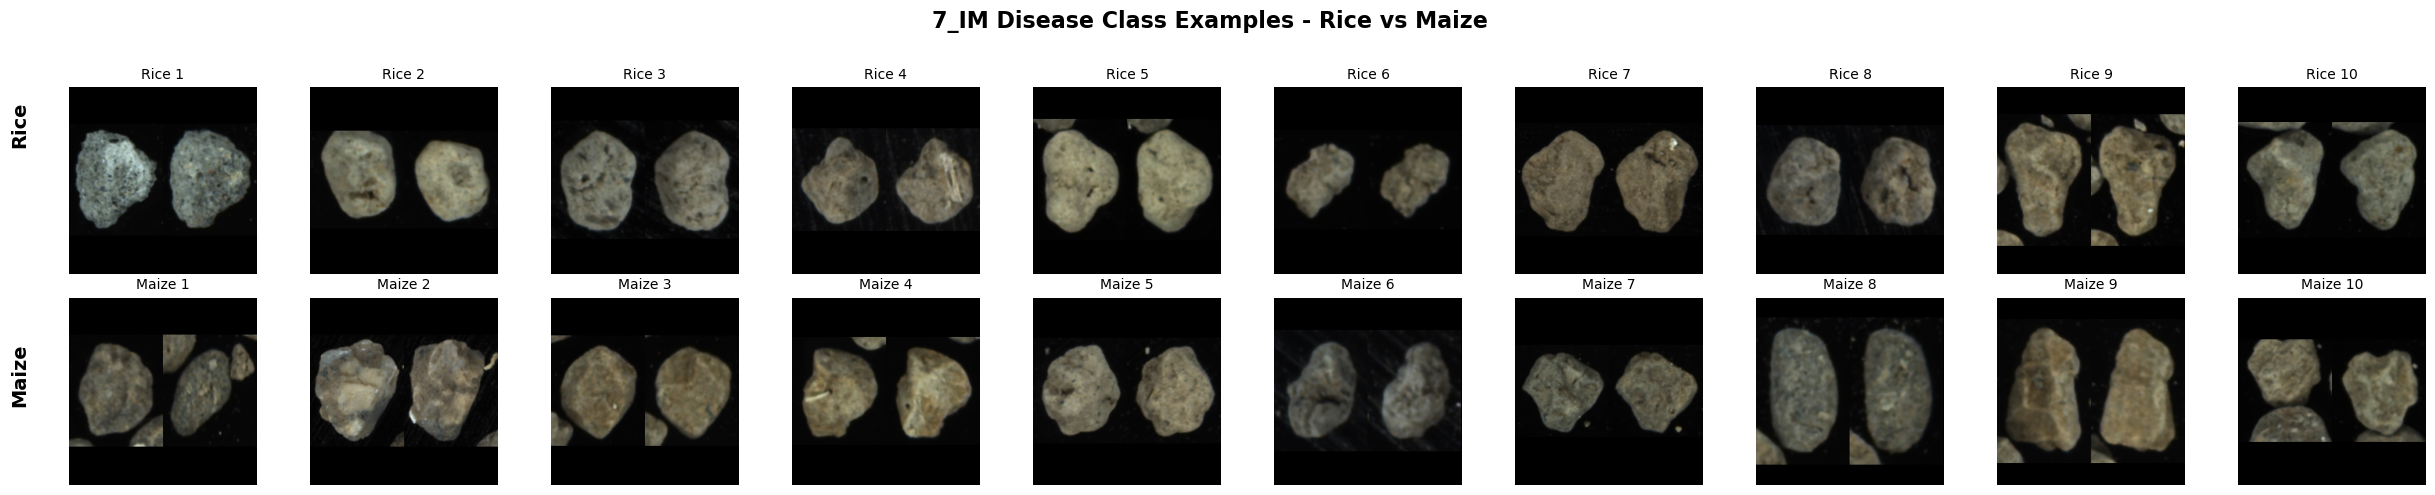

Rice 7_IM samples found: 10 (displayed 10)
Maize 7_IM samples found: 10 (displayed 10)

Total Rice 7_IM images: 1530
Total Maize 7_IM images: 2295


In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import numpy as np

# Define paths to 7_IM directories
rice_path = Path("dataset/images/rice/train/7_IM")
maize_path = Path("dataset/images/maize/train/7_IM")

# Get list of images
rice_images = sorted(list(rice_path.glob("*.png")))[:10]  # Get first 10
maize_images = sorted(list(maize_path.glob("*.png")))[:10]  # Get first 10

# Create figure with subplots
fig, axes = plt.subplots(2, 10, figsize=(25, 5))
fig.suptitle(
    "7_IM Disease Class Examples - Rice vs Maize", fontsize=16, fontweight="bold"
)

# Display rice images
for idx, img_path in enumerate(rice_images):
    img = mpimg.imread(img_path)
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f"Rice {idx+1}", fontsize=10)
    axes[0, idx].axis("off")

# Display maize images
for idx, img_path in enumerate(maize_images):
    img = mpimg.imread(img_path)
    axes[1, idx].imshow(img)
    axes[1, idx].set_title(f"Maize {idx+1}", fontsize=10)
    axes[1, idx].axis("off")

# Label rows
fig.text(
    0.02, 0.75, "Rice", va="center", fontsize=14, fontweight="bold", rotation="vertical"
)
fig.text(
    0.02,
    0.25,
    "Maize",
    va="center",
    fontsize=14,
    fontweight="bold",
    rotation="vertical",
)

plt.tight_layout(rect=[0.03, 0, 1, 0.96])
plt.show()

# Print sample image information
print(f"Rice 7_IM samples found: {len(rice_images)} (displayed 10)")
print(f"Maize 7_IM samples found: {len(maize_images)} (displayed 10)")
print(f"\nTotal Rice 7_IM images: {len(list(rice_path.glob('*.png')))}")
print(f"Total Maize 7_IM images: {len(list(maize_path.glob('*.png')))}")